# MegNIST paper reproduction

This Colab notebook reproduces the **computational analysis figures (Figures 5–8)**
in the MegNIST *Scientific Data* manuscript from the public release.

- **Figure 5:** model selection and generalisation
- **Figure 6:** label-permutation significance test
- **Figure 7:** temporal permutation feature importance (PFI)
- **Figure 8:** planar-gradiometer RMS topographies

Figures 1–4 are experimental/data-organisation schematics rather than outputs of
the validation analysis, so they are not regenerated here.

The notebook is intentionally the **quick paper-reproduction path**: expensive
model training is not run by default. The complete 7-architecture × 10-seed
training procedure is provided separately in
`scripts/run_hyperparameter_search.py`.


In [2]:
# Colab setup
# The final public release should install PNPL exactly as described in the paper.
# %pip install -q pnpl

%pip install -q \
    "numpy>=1.24,<3" \
    "scipy>=1.10,<2" \
    "matplotlib>=3.7,<4" \
    "h5py>=3.10,<4" \
    "mne>=1.4.2,<2" \
    "huggingface-hub>=0.19" \
    "seaborn>=0.13,<1" \
    "tqdm>=4.66"

# Before the updated PNPL release reaches PyPI, developers can instead use:
%pip install -q "git+https://github.com/neural-processing-lab/pnpl.git@main"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.7/7.7 MB 46.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
moviepy 1.0.3 requires decorator<5.0,>=4.0.2, but you have decorator 5.3.1 which is incompatible.
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 189.8/189.8 kB 5.0 MB/s eta 0:00:00


In [3]:
from pathlib import Path
import gc
import math
import pickle
import shutil
import time
import urllib.request

import h5py
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
import mne
import numpy as np
from scipy import stats
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from huggingface_hub import hf_hub_download
from tqdm.auto import tqdm

HF_REPO = "pnpl/MegNIST"
PAPER_REPO_RAW = "https://raw.githubusercontent.com/neural-processing-lab/megnist-paper/main"
MODEL_RELEASE_URL = "https://github.com/neural-processing-lab/megnist-paper/releases/download/v1.0/baseline_model_seed47.pth"

WORK_DIR = Path("/content/MegNIST_paper")
DATA_DIR = WORK_DIR / "data"
FIG_DIR = WORK_DIR / "figures"
CACHE_DIR = WORK_DIR / "cache"
for p in (DATA_DIR, FIG_DIR, CACHE_DIR):
    p.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_SEED = 47
ANALYSIS_SEED = 42
N_PERMUTATIONS = 100_000
PFI_REPEATS = 10
PFI_WINDOW_SAMPLES = 25
PFI_ALPHA = 0.05

print("Device:", DEVICE)
print("Work directory:", WORK_DIR)

def get_paper_file(relative_path):
    """Return a small paper-result file, downloading it from GitHub if needed."""
    relative_path = Path(relative_path)

    # If running from a clone of megnist-paper, use the local file.
    if relative_path.exists():
        return relative_path

    # Colab opened directly from GitHub does not clone sibling repo files.
    # Cache the small public result locally instead.
    cached_path = CACHE_DIR / relative_path.name
    if not cached_path.exists():
        url = f"{PAPER_REPO_RAW}/{relative_path.as_posix()}"
        print(f"Downloading paper result: {url}")
        urllib.request.urlretrieve(url, cached_path)

    return cached_path


Device: cuda
Work directory: /content/MegNIST_paper


## 1. PNPL loader smoke test

This first uses the new public `MegNIST` loader exactly as a user would. We keep `standardize=False` because the paper uses its own **training-fitted feature-wise standardisation** rather than PNPL's optional channel-wise normalisation.

In [4]:
from pnpl.datasets import MegNIST

smoke = MegNIST(
    data_path=str(DATA_DIR),
    partition="validation",
    standardize=False,
)
x0, y0 = smoke[0]

print("validation samples:", len(smoke))
print("sample shape:", tuple(x0.shape))
print("first label:", int(y0))
print("sampling frequency:", smoke.sfreq)

assert len(smoke) == 1000
assert tuple(x0.shape) == (306, 250)
assert smoke.sfreq == 250.0

del smoke, x0, y0
gc.collect()

derivatives/serialised/val.h5: reconstructing file:   0%|          |  0.00B /  306MB            

derivatives/serialised/val.h5: downloading bytes:           |  0.00B            

validation samples: 1000
sample shape: (306, 250)
first label: 0
sampling frequency: 250.0


261

## 2. Download the released paper artefacts

The notebook uses the released train/validation/test HDF5 files from Hugging Face,
the representative seed-47 checkpoint from the GitHub `v1.0` release, and the
small paper-specific result files stored under `results/` in this GitHub repository.
All are public.


In [5]:
REMOTE_FILES = {
    "train": "derivatives/serialised/train.h5",
    "val": "derivatives/serialised/val.h5",
    "test": "derivatives/serialised/test.h5",
}

paths = {}
for key, filename in REMOTE_FILES.items():
    print(f"{key:>7}: {filename}")
    paths[key] = Path(
        hf_hub_download(
            repo_id=HF_REPO,
            repo_type="dataset",
            filename=filename,
            local_dir=DATA_DIR,
        )
    )

for split, expected_n in [("train", 10_000), ("val", 1_000), ("test", 1_000)]:
    with h5py.File(paths[split], "r") as f:
        assert f["data"].shape == (expected_n, 306, 250)
        assert f["labels"].shape == (expected_n,)
        times = np.asarray(f["times"][:], dtype=float)
        sfreq = float(round(1.0 / np.median(np.diff(times))))
        assert sfreq == 250.0
        print(
            f"{split:>5}: {f['data'].shape}, "
            f"time={times[0]*1000:.1f}..{times[-1]*1000:.1f} ms, "
            f"sfreq={sfreq:.1f} Hz"
        )

  train: derivatives/serialised/train.h5


derivatives/serialised/train.h5: reconstructing file:   0%|          |  0.00B / 3.06GB            

derivatives/serialised/train.h5: downloading bytes:           |  0.00B            

    val: derivatives/serialised/val.h5
   test: derivatives/serialised/test.h5


derivatives/serialised/test.h5: reconstructing file:   0%|          |  0.00B /  306MB            

derivatives/serialised/test.h5: downloading bytes:           |  0.00B            

train: (10000, 306, 250), time=-48.0..948.0 ms, sfreq=250.0 Hz
  val: (1000, 306, 250), time=-48.0..948.0 ms, sfreq=250.0 Hz
 test: (1000, 306, 250), time=-48.0..948.0 ms, sfreq=250.0 Hz


## 3. Reproduce the paper's training-set standardisation

The released representative model was trained on flattened 306 × 250 epochs using one mean and standard deviation for **each sensor–time feature**. Statistics were computed from the 10,000 training trials only and then reused unchanged for validation and test data.

The code below reproduces the original sequential **Welford** calculation. The result is cached locally so it only needs to be computed once per Colab workspace.

In [6]:
STATS_CACHE = CACHE_DIR / "training_feature_standardisation_welford.npz"

def compute_feature_statistics_welford(h5_path, batch_size=1000):
    # Exact Welford procedure used by the released baseline training code.
    start_time = time.time()

    with h5py.File(h5_path, "r") as f:
        n_samples = len(f["data"])
        sample_shape = f["data"][0].shape
        n_features = int(np.prod(sample_shape))

        mean = np.zeros(n_features, dtype=np.float64)
        M2 = np.zeros(n_features, dtype=np.float64)
        count = 0

        starts = range(0, n_samples, batch_size)
        for start_idx in tqdm(
            starts,
            total=math.ceil(n_samples / batch_size),
            desc="Training statistics",
        ):
            end_idx = min(start_idx + batch_size, n_samples)
            batch = f["data"][start_idx:end_idx]
            batch_flat = batch.reshape(batch.shape[0], -1)

            # Deliberately sequential: matches the released training implementation.
            for row in batch_flat:
                count += 1
                delta = row - mean
                mean += delta / count
                delta2 = row - mean
                M2 += delta * delta2

        std = np.sqrt(M2 / count)
        std[std == 0] = 1.0

    print(
        f"Computed statistics from {count:,} training samples "
        f"in {time.time() - start_time:.1f} s"
    )
    return mean, std, count


if STATS_CACHE.exists():
    cached = np.load(STATS_CACHE)
    train_mean = cached["mean"]
    train_std = cached["std"]
    train_count = int(cached["count"])
    print("Loaded cached training standardisation:", STATS_CACHE)
else:
    train_mean, train_std, train_count = compute_feature_statistics_welford(
        paths["train"]
    )
    np.savez_compressed(
        STATS_CACHE,
        mean=train_mean,
        std=train_std,
        count=np.asarray(train_count),
    )
    print("Saved:", STATS_CACHE)

assert train_count == 10_000
assert train_mean.shape == (306 * 250,)
assert train_std.shape == (306 * 250,)
print("features:", len(train_mean))

Training statistics:   0%|          | 0/10 [00:00<?, ?it/s]

Computed statistics from 10,000 training samples in 7.3 s
Saved: /content/MegNIST_paper/cache/training_feature_standardisation_welford.npz
features: 76500


In [7]:
class PaperH5Dataset(Dataset):
    def __init__(self, h5_path, mean, std):
        self.h5_path = str(h5_path)
        self.mean = mean
        self.std = std
        with h5py.File(self.h5_path, "r") as f:
            self.length = len(f["data"])
            self.data_shape = tuple(f["data"].shape[1:])

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        with h5py.File(self.h5_path, "r") as f:
            x = np.asarray(f["data"][idx]).reshape(-1)
            y = int(f["labels"][idx])

        # Same numerical path as released training:
        # float32 raw -> float64 Welford stats -> float32 tensor.
        x = ((x - self.mean) / self.std).astype(np.float32, copy=False)
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


def make_loader(h5_path, batch_size=32):
    return DataLoader(
        PaperH5Dataset(h5_path, train_mean, train_std),
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

val_loader = make_loader(paths["val"])
test_loader = make_loader(paths["test"])

## 4. Load and verify the released representative model

The paper's selected architecture has one hidden layer with **1,024 units**, ReLU activation and a 10-way output. The representative model is **seed 47**.

In [8]:
model_path = CACHE_DIR / "baseline_model_seed47.pth"
if not model_path.exists():
    print(f"Downloading released baseline model: {MODEL_RELEASE_URL}")
    urllib.request.urlretrieve(MODEL_RELEASE_URL, model_path)

print("Baseline model:", model_path)

class SimpleMLP(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes=10):
        super().__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)

    def forward(self, x):
        return self.fc2(self.relu(self.fc1(x)))


checkpoint = torch.load(model_path, map_location=DEVICE, weights_only=False)
arch = checkpoint["architecture"]

model = SimpleMLP(
    input_size=int(arch["input_size"]),
    hidden_size=int(arch["hidden_size"]),
    num_classes=int(arch["output_size"]),
).to(DEVICE)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("architecture:", arch)
print("training info:", checkpoint.get("training_info", {}))


def predict_loader(model, loader, device):
    ys, preds = [], []
    model.eval()
    with torch.inference_mode():
        for x, y in tqdm(loader, leave=False):
            logits = model(x.to(device, non_blocking=True))
            pred = logits.argmax(dim=1).cpu()
            ys.append(y.cpu())
            preds.append(pred)
    return torch.cat(ys).numpy(), torch.cat(preds).numpy()


y_val, pred_val = predict_loader(model, val_loader, DEVICE)
y_test, pred_test = predict_loader(model, test_loader, DEVICE)

val_acc = 100 * np.mean(pred_val == y_val)
test_acc = 100 * np.mean(pred_test == y_test)

print(f"Validation accuracy: {val_acc:.1f}%")
print(f"Test accuracy:       {test_acc:.1f}%")

assert np.isclose(val_acc, 27.1, atol=0.05), val_acc
assert np.isclose(test_acc, 22.6, atol=0.05), test_acc

Baseline model: /content/MegNIST_paper/cache/baseline_model_seed47.pth
architecture: {'input_size': np.int64(76500), 'hidden_size': 1024, 'output_size': 10}
training info: {'seed': 47, 'val_accuracy': np.float64(27.1), 'test_accuracy': np.float64(22.6), 'best_epoch': 16}


  0%|          | 0/32 [00:00<?, ?it/s]

  0%|          | 0/32 [00:00<?, ?it/s]

Validation accuracy: 27.1%
Test accuracy:       22.6%


# Figure 5 — Model selection and generalisation

The figure is generated from the released 7-architecture × 10-seed search
results. Plotting matches the manuscript: half-violins, white box plots,
individual coloured seed points, green→yellow→orange palette, pale-blue
highlighting of the selected 1,024-unit model, and a yellow star in the
validation panel.

For exact from-scratch retraining, use
`scripts/run_hyperparameter_search.py`. That script runs the seven hidden-layer
sizes (32–2,048) across seeds 42–51 with the optimisation and early-stopping
settings reported in the paper. It is kept separate from this notebook because
the full 70-model search is slow; this notebook loads the released search
results by default.


Architecture results: /content/MegNIST_paper/cache/all_architectures.pkl


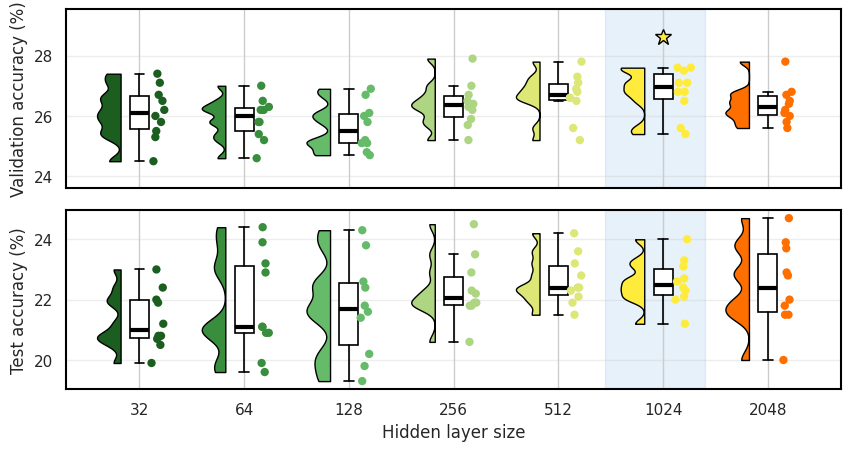

Best architecture by mean validation accuracy: 1024
1024 validation: 26.8 ± 0.7%
1024 test:       22.6 ± 0.7%


In [9]:
architecture_results_path = get_paper_file("results/all_architectures.pkl")
print("Architecture results:", architecture_results_path)

with open(architecture_results_path, "rb") as f:
    architecture_results = pickle.load(f)

architectures = [int(v) for v in architecture_results["architectures"]]
val_data = {
    int(h): np.asarray(architecture_results["val_accuracies"][h], dtype=float)
    for h in architecture_results["val_accuracies"]
}
test_data = {
    int(h): np.asarray(architecture_results["test_accuracies"][h], dtype=float)
    for h in architecture_results["test_accuracies"]
}

pineapple_bold = [
    "#1B5E20", "#388E3C", "#66BB6A", "#AED581",
    "#DCE775", "#FFEB3B", "#FF6F00",
]

sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans"],
    "font.size": 12,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
})


def raincloud_panel(ax, values_by_arch, ylabel, seed):
    positions = np.arange(len(architectures))
    rng = np.random.default_rng(seed)

    violin = ax.violinplot(
        [values_by_arch[h] for h in architectures],
        positions=positions - 0.18,
        widths=0.45,
        showmeans=False,
        showmedians=False,
        showextrema=False,
        bw_method=0.2,
    )
    for i, body in enumerate(violin["bodies"]):
        body.set_facecolor(pineapple_bold[i])
        body.set_edgecolor("black")
        body.set_alpha(1.0)
        verts = body.get_paths()[0].vertices
        center = positions[i] - 0.18
        verts[:, 0] = np.minimum(verts[:, 0], center)

    ax.boxplot(
        [values_by_arch[h] for h in architectures],
        positions=positions,
        widths=0.18,
        patch_artist=True,
        showfliers=False,
        boxprops=dict(facecolor="white", edgecolor="black", linewidth=1.2),
        whiskerprops=dict(color="black", linewidth=1.2),
        capprops=dict(color="black", linewidth=1.2),
        medianprops=dict(color="black", linewidth=3.0),
    )

    for i, h in enumerate(architectures):
        y = values_by_arch[h]
        x = positions[i] + 0.18 + rng.normal(0, 0.035, len(y))
        ax.scatter(
            x, y,
            s=36,
            color=pineapple_bold[i],
            edgecolors="none",
            alpha=1.0,
            zorder=5,
        )

    ax.set_ylabel(ylabel)
    ax.set_xticks(positions)
    ax.set_xticklabels(architectures)
    ax.grid(True, alpha=0.35, axis="y")
    for spine in ax.spines.values():
        spine.set_edgecolor("black")
        spine.set_linewidth(1.5)


fig, axes = plt.subplots(2, 1, figsize=(10, 5), sharex=True)
raincloud_panel(axes[0], val_data, "Validation accuracy (%)", seed=5)
raincloud_panel(axes[1], test_data, "Test accuracy (%)", seed=11)

selected_idx = architectures.index(1024)
for ax in axes:
    ax.axvspan(
        selected_idx - 0.55,
        selected_idx + 0.40,
        color="#1976D2",
        alpha=0.1,
        zorder=0,
    )
    xmin, xmax = ax.get_xlim()
    ax.set_xlim(xmin - 0.1, xmax + 0.1)

axes[0].set_xlabel("")
axes[1].set_xlabel("Hidden layer size")
axes[0].plot(
    selected_idx,
    axes[0].get_ylim()[1] * 1.02,
    marker="*",
    markersize=12,
    color="black",
    markerfacecolor="#FFEB3B",
    zorder=10,
)

# Give the two panels the same vertical span, as in the manuscript figure.
val_range = axes[0].get_ylim()
test_range = axes[1].get_ylim()
max_span = max(
    val_range[1] - val_range[0],
    test_range[1] - test_range[0],
)
val_center = sum(val_range) / 2
test_center = sum(test_range) / 2
axes[0].set_ylim(
    val_center - max_span / 2,
    val_center + max_span / 2,
)
axes[1].set_ylim(
    test_center - max_span / 2,
    test_center + max_span / 2,
)

# Matplotlib 3.10 can emit a harmless tight_layout warning for this raincloud
# composition. subplots_adjust avoids the warning without changing the plot.
fig.subplots_adjust(hspace=0.12, bottom=0.12)

fig.savefig(
    FIG_DIR / "figure5_model_selection.pdf",
    bbox_inches="tight",
    transparent=False,
    facecolor="white",
)
fig.savefig(
    FIG_DIR / "figure5_model_selection.png",
    dpi=300,
    bbox_inches="tight",
    transparent=False,
    facecolor="white",
)
plt.show()

means = {h: np.mean(val_data[h]) for h in architectures}
best_arch = max(means, key=means.get)

print("Best architecture by mean validation accuracy:", best_arch)
print(
    f"1024 validation: {np.mean(val_data[1024]):.1f} ± "
    f"{np.std(val_data[1024]):.1f}%"
)
print(
    f"1024 test:       {np.mean(test_data[1024]):.1f} ± "
    f"{np.std(test_data[1024]):.1f}%"
)

assert best_arch == 1024

## Optional check — within-run standardisation

The paper notes an exploratory alternative in which each recording run is
standardised using that run's own per-feature mean and standard deviation.
The main reported baseline does **not** use this procedure: it uses training-set
statistics only.

The block below can retrain the selected 1,024-unit MLP across the same ten
seeds (42–51) using within-run standardisation and compare it with the reported
baseline. It is disabled by default because it requires substantial retraining.

For the training split, the serialised file contains ten consecutive 1,000-trial
runs; validation and test each contain one 1,000-trial run. The serialisation
pipeline preserves this chronological run order. Because validation and test
are normalised using statistics from their own (unlabelled) run, this is an
exploratory run-wise normalisation analysis rather than the strict
training-statistics-only preprocessing used for the primary baseline.


In [10]:
RUN_WITHIN_RUN_CHECK = False
WITHIN_RUN_SEEDS = list(range(42, 52))


def compute_runwise_statistics(h5_path, run_size=1000):
    """Per-feature population mean/std independently for each consecutive run."""
    with h5py.File(h5_path, "r") as f:
        n = len(f["data"])
        if n % run_size != 0:
            raise ValueError(f"{h5_path}: {n} samples is not divisible by {run_size}")

        n_runs = n // run_size
        n_features = int(np.prod(f["data"].shape[1:]))
        means = np.empty((n_runs, n_features), dtype=np.float64)
        stds = np.empty((n_runs, n_features), dtype=np.float64)

        for run_idx in tqdm(range(n_runs), desc=f"Run-wise stats: {Path(h5_path).name}"):
            start = run_idx * run_size
            stop = start + run_size

            # Same sequential Welford calculation used for the main baseline,
            # now restarted independently for each recording run.
            mean = np.zeros(n_features, dtype=np.float64)
            M2 = np.zeros(n_features, dtype=np.float64)
            count = 0

            for row in f["data"][start:stop]:
                x = np.asarray(row).reshape(-1)
                count += 1
                delta = x - mean
                mean += delta / count
                delta2 = x - mean
                M2 += delta * delta2

            std = np.sqrt(M2 / count)
            std[std == 0] = 1.0
            means[run_idx] = mean
            stds[run_idx] = std

    return means, stds


class RunWiseH5Dataset(Dataset):
    def __init__(self, h5_path, means, stds, run_size=1000):
        self.h5_path = str(h5_path)
        self.means = means
        self.stds = stds
        self.run_size = run_size
        with h5py.File(self.h5_path, "r") as f:
            self.length = len(f["data"])

    def __len__(self):
        return self.length

    def __getitem__(self, idx):
        run_idx = idx // self.run_size
        with h5py.File(self.h5_path, "r") as f:
            x = np.asarray(f["data"][idx]).reshape(-1)
            y = int(f["labels"][idx])

        x = (
            (x - self.means[run_idx]) / self.stds[run_idx]
        ).astype(np.float32, copy=False)
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


def set_training_seed(seed):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def evaluate_accuracy(model, loader):
    y, pred = predict_loader(model, loader, DEVICE)
    return 100 * np.mean(y == pred)


def train_within_run_seed(seed, train_stats, val_stats, test_stats):
    set_training_seed(seed)

    train_ds = RunWiseH5Dataset(paths["train"], *train_stats)
    val_ds = RunWiseH5Dataset(paths["val"], *val_stats)
    test_ds = RunWiseH5Dataset(paths["test"], *test_stats)

    generator = torch.Generator().manual_seed(seed)
    train_loader_wr = DataLoader(
        train_ds,
        batch_size=32,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    val_loader_wr = DataLoader(
        val_ds, batch_size=32, shuffle=False, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )
    test_loader_wr = DataLoader(
        test_ds, batch_size=32, shuffle=False, num_workers=0,
        pin_memory=torch.cuda.is_available(),
    )

    m = SimpleMLP(306 * 250, 1024, 10).to(DEVICE)
    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.AdamW(m.parameters(), lr=1e-3)

    best_state = None
    best_val = -np.inf
    patience_left = 20

    for epoch in range(200):
        m.train()
        for x, y in train_loader_wr:
            x = x.to(DEVICE, non_blocking=True)
            y = y.to(DEVICE, non_blocking=True)
            optimizer.zero_grad()
            loss = criterion(m(x), y)
            loss.backward()
            optimizer.step()

        val_acc_wr = evaluate_accuracy(m, val_loader_wr)
        if val_acc_wr > best_val:
            best_val = val_acc_wr
            best_state = {
                k: v.detach().cpu().clone()
                for k, v in m.state_dict().items()
            }
            patience_left = 20
        else:
            patience_left -= 1
            if patience_left == 0:
                break

    m.load_state_dict(best_state)
    m.to(DEVICE)
    test_acc_wr = evaluate_accuracy(m, test_loader_wr)

    del train_loader_wr, val_loader_wr, test_loader_wr, m
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    return best_val, test_acc_wr


if RUN_WITHIN_RUN_CHECK:
    stats_cache = CACHE_DIR / "within_run_standardisation_stats.npz"

    if stats_cache.exists():
        s = np.load(stats_cache)
        train_stats_wr = (s["train_mean"], s["train_std"])
        val_stats_wr = (s["val_mean"], s["val_std"])
        test_stats_wr = (s["test_mean"], s["test_std"])
        print("Loaded cached within-run statistics:", stats_cache)
    else:
        train_stats_wr = compute_runwise_statistics(paths["train"])
        val_stats_wr = compute_runwise_statistics(paths["val"])
        test_stats_wr = compute_runwise_statistics(paths["test"])
        np.savez_compressed(
            stats_cache,
            train_mean=train_stats_wr[0],
            train_std=train_stats_wr[1],
            val_mean=val_stats_wr[0],
            val_std=val_stats_wr[1],
            test_mean=test_stats_wr[0],
            test_std=test_stats_wr[1],
        )

    within_results = []
    for seed in WITHIN_RUN_SEEDS:
        print(f"\nWithin-run standardisation — seed {seed}")
        va, te = train_within_run_seed(
            seed, train_stats_wr, val_stats_wr, test_stats_wr
        )
        within_results.append((seed, va, te))
        print(f"  val={va:.2f}%  test={te:.2f}%")

    within_val = np.array([r[1] for r in within_results])
    within_test = np.array([r[2] for r in within_results])

    global_val = np.asarray(val_data[1024], dtype=float)
    global_test = np.asarray(test_data[1024], dtype=float)

    print("\n1024-unit MLP, 10 seeds")
    print(
        f"Training-set standardisation: "
        f"val {global_val.mean():.2f} ± {global_val.std():.2f}%, "
        f"test {global_test.mean():.2f} ± {global_test.std():.2f}%"
    )
    print(
        f"Within-run standardisation:   "
        f"val {within_val.mean():.2f} ± {within_val.std():.2f}%, "
        f"test {within_test.mean():.2f} ± {within_test.std():.2f}%"
    )
    print(
        f"Difference (within-run - main): "
        f"val {within_val.mean() - global_val.mean():+.2f} pp, "
        f"test {within_test.mean() - global_test.mean():+.2f} pp"
    )
else:
    print(
        "Within-run standardisation check skipped. "
        "Set RUN_WITHIN_RUN_CHECK=True to retrain the 1024-unit model across seeds 42–51."
    )


Within-run standardisation check skipped. Set RUN_WITHIN_RUN_CHECK=True to retrain the 1024-unit model across seeds 42–51.


# Figure 6 — Decoding significance

Predictions from the released representative model are held fixed and test labels
are randomly shuffled **100,000 times**. The empirical one-sided p-value uses the
standard **+1 correction**.


Label permutations:   0%|          | 0/100000 [00:00<?, ?it/s]

Observed accuracy:        22.60%
Null median:              10.00%
Null mean ± SD:           10.00 ± 0.94%
99th percentile:          12.20%
Permutations >= observed: 0
+1 corrected p-value:     0.00001000


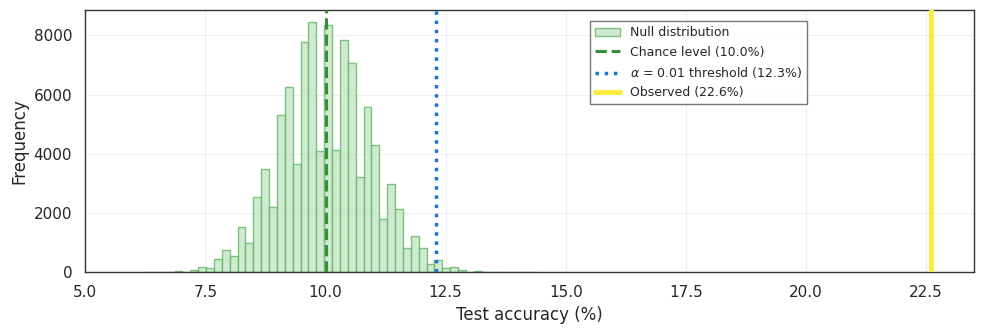

In [15]:
# RNG used to generate the manuscript Figure 6.
rng_perm = np.random.default_rng(47)

observed_test_acc = 100 * np.mean(pred_test == y_test)
null_accs = np.empty(N_PERMUTATIONS, dtype=np.float32)

for i in tqdm(range(N_PERMUTATIONS), desc="Label permutations"):
    shuffled_labels = rng_perm.permutation(y_test)
    null_accs[i] = 100 * np.mean(pred_test == shuffled_labels)

chance_level = 10.0
alpha = 0.01

# Descriptive 99th percentile of the discrete null distribution.
percentile_99 = float(np.percentile(null_accs, 99))

# Smallest attainable accuracy whose one-sided empirical p-value is <= alpha.
candidate_accs = np.sort(np.unique(null_accs))
candidate_pvalues = np.array([
    (np.sum(null_accs >= acc) + 1) / (N_PERMUTATIONS + 1)
    for acc in candidate_accs
])
critical_threshold = float(
    candidate_accs[np.flatnonzero(candidate_pvalues <= alpha)[0]]
)

# Empirical p-value for the observed seed-47 test accuracy.
n_extreme = int(np.sum(null_accs >= observed_test_acc))
p_value = (n_extreme + 1) / (N_PERMUTATIONS + 1)

print(f"Observed accuracy:        {observed_test_acc:.2f}%")
print(f"Null median:              {np.median(null_accs):.2f}%")
print(f"Null mean ± SD:           {np.mean(null_accs):.2f} ± {np.std(null_accs):.2f}%")
print(f"99th percentile:          {threshold_99:.2f}%")
print(f"Permutations >= observed: {n_extreme}")
print(f"+1 corrected p-value:     {p_value:.8f}")

assert np.isclose(observed_test_acc, 22.6, atol=0.05), observed_test_acc

np.savez_compressed(
    CACHE_DIR / "figure6_permutation_test_seed42.npz",
    observed_test_acc=observed_test_acc,
    null_accs=null_accs,
    threshold_99=threshold_99,
    p_value=p_value,
    seed=ANALYSIS_SEED,
)

fig, ax = plt.subplots(figsize=(10, 3.5))

ax.hist(
    null_accs,
    bins=50,
    color="#C8E6C9",
    alpha=0.85,
    edgecolor="#66BB6A",
    linewidth=1.0,
    label="Null distribution",
)
ax.axvline(
    chance_level,
    color="#388E3C",
    linestyle="--",
    linewidth=2.2,
    label=f"Chance level ({chance_level:.1f}%)",
    zorder=5,
)
ax.axvline(
    critical_threshold,
    color="#1976D2",
    linestyle=":",
    linewidth=2.5,
    label=rf"$\alpha$ = 0.01 threshold ({critical_threshold:.1f}%)",
    zorder=5,
)
ax.axvline(
    observed_test_acc,
    color="#FFEB3B",
    linestyle="-",
    linewidth=3.5,
    label=f"Observed ({observed_test_acc:.1f}%)",
    zorder=10,
)

ax.set_xlabel("Test accuracy (%)")
ax.set_ylabel("Frequency")
ax.set_xlim(5.0, 23.5)
ax.grid(alpha=0.30, linewidth=0.8)
ax.legend(
    loc="upper center",
    bbox_to_anchor=(0.69, 0.98),
    frameon=True,
    fancybox=False,
    edgecolor="#555555",
    fontsize=9,
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#333333")
    spine.set_linewidth(1.0)

fig.tight_layout()
fig.savefig(
    FIG_DIR / "figure6_permutation_test.pdf",
    bbox_inches="tight",
    facecolor="white",
)
fig.savefig(
    FIG_DIR / "figure6_permutation_test.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

# Figure 7 — Temporal permutation feature importance

Following Csaky et al. (2023), temporal PFI is computed with sliding ~100-ms
windows. Within each trial, the MEG data in the current window are permuted across
the channel dimension while the remainder of the epoch is left unchanged. The
resulting drop in validation accuracy measures the importance of that temporal
window to the trained full-epoch decoder.

By default, the notebook loads `results/pfi.npz`, the cached result used to generate
the manuscript figure. Set `RECOMPUTE_PFI=True` below to rerun the stochastic
perturbation analysis from the released model and validation data.


In [16]:
PAPER_PFI_FILE = "results/pfi.npz"
RECOMPUTE_PFI = False

# Historical plotting convention: the cached temporal axis was shifted by
# 50 ms when the manuscript figure was made.
PAPER_TIME_OFFSET_MS = -50.0


def load_standardised_split_3d(h5_path, mean, std, batch_size=100):
    with h5py.File(h5_path, "r") as f:
        n, c, t = f["data"].shape
        y = np.asarray(f["labels"][:], dtype=np.int64)
        times = np.asarray(f["times"][:], dtype=np.float64)
        out = np.empty((n, c, t), dtype=np.float32)

        for start in tqdm(
            range(0, n, batch_size),
            desc="Standardising validation",
        ):
            stop = min(start + batch_size, n)
            raw = np.asarray(f["data"][start:stop])
            flat = raw.reshape(stop - start, -1)
            z = (flat - mean[None, :]) / std[None, :]
            out[start:stop] = z.reshape(stop - start, c, t).astype(np.float32)

    return out, y, times


def accuracy_from_3d(model, x3d, labels, device):
    x = torch.from_numpy(x3d.reshape(len(x3d), -1)).to(device)
    y = torch.from_numpy(labels).to(device)
    with torch.inference_mode():
        pred = model(x).argmax(dim=1)
    return 100 * (pred == y).float().mean().item()


def temporal_channel_permutation_importance(
    model,
    x3d,
    labels,
    times,
    device,
    n_repeats=10,
    window_size=25,
    seed=42,
):
    """Fresh, reproducible rerun of the released temporal perturbation method."""
    n_samples, n_channels, n_timepoints = x3d.shape

    baseline_acc = accuracy_from_3d(model, x3d, labels, device)
    print(f"Baseline validation accuracy: {baseline_acc:.2f}%")

    all_shuffled_accs = np.zeros(
        (n_timepoints, n_repeats),
        dtype=np.float32,
    )

    rng = np.random.RandomState(seed)

    for t_center in tqdm(range(n_timepoints), desc="Temporal windows"):
        t_start = max(0, t_center - window_size // 2)
        t_end = min(
            n_timepoints,
            t_center + window_size // 2 + 1,
        )

        for rep in range(n_repeats):
            x_shuffled = x3d.copy()

            for sample_idx in range(n_samples):
                permutation = rng.permutation(n_channels)
                x_shuffled[
                    sample_idx, :, t_start:t_end
                ] = x_shuffled[
                    sample_idx, permutation, t_start:t_end
                ]

            all_shuffled_accs[t_center, rep] = accuracy_from_3d(
                model,
                x_shuffled,
                labels,
                device,
            )

    drops = baseline_acc - all_shuffled_accs
    importance = drops.mean(axis=1)
    importance_std = all_shuffled_accs.std(axis=1)
    pvalues = np.array([
        stats.ttest_1samp(
            drops[t],
            0.0,
            alternative="greater",
        ).pvalue
        for t in range(n_timepoints)
    ])

    threshold = PFI_ALPHA / n_timepoints
    sig_mask = pvalues < threshold
    peak_idx = int(np.argmax(importance))

    return {
        "importance_mean": importance,
        "importance_std": importance_std,
        "pvalues": pvalues,
        "sig_mask": sig_mask,
        "n_repeats": np.asarray(n_repeats),
        "window_size_ms": np.asarray(window_size / 250.0 * 1000.0),
        "time_ms": times * 1000.0,
        "peak_time_ms": np.asarray(times[peak_idx] * 1000.0),
        "baseline_acc": np.asarray(baseline_acc),
        "all_shuffled_accs": all_shuffled_accs,
        "seed": np.asarray(seed),
    }


if not RECOMPUTE_PFI:
    # Exact manuscript result.
    paper_pfi_path = get_paper_file(PAPER_PFI_FILE)
    cached = np.load(paper_pfi_path)

    required = {
        "time_ms",
        "importance_mean",
        "importance_std",
        "pvalues",
        "sig_mask",
        "window_size_ms",
        "peak_time_ms",
        "n_repeats",
    }
    missing = required - set(cached.files)
    if missing:
        raise KeyError(
            f"{paper_pfi_path.name} is missing expected keys: {sorted(missing)}"
        )

    importance = np.asarray(cached["importance_mean"], dtype=float)
    std = np.asarray(cached["importance_std"], dtype=float)
    pvalues = np.asarray(cached["pvalues"], dtype=float)
    significant = np.asarray(cached["sig_mask"], dtype=bool)
    n_repeats_fig7 = int(np.asarray(cached["n_repeats"]))
    window_size_ms_fig7 = float(np.asarray(cached["window_size_ms"]))

    # Preserve the coordinate convention used to make the manuscript plot.
    times_ms = (
        np.asarray(cached["time_ms"], dtype=float)
        + PAPER_TIME_OFFSET_MS
    )
    peak_idx = int(np.argmax(importance))
    peak_time_ms = float(times_ms[peak_idx])
    peak_importance = float(importance[peak_idx])
    bonferroni_threshold = PFI_ALPHA / len(importance)
    baseline_acc_fig7 = np.nan

    print("Figure 7 source: released historical cache")
    print("Cache:", paper_pfi_path)
    # Guard the historical result used by the manuscript figure.
    assert np.isclose(peak_time_ms, 242.0, atol=2.1), peak_time_ms
    assert np.isclose(peak_importance, 4.8, atol=0.15), peak_importance

else:
    # Fresh rerun. This is method reproduction, not an attempt to recover the
    # unrecorded RNG state of the historical stochastic realisation.
    x_val_3d, y_val_3d, val_times = load_standardised_split_3d(
        paths["val"],
        train_mean,
        train_std,
    )

    rerun = temporal_channel_permutation_importance(
        model,
        x_val_3d,
        y_val_3d,
        val_times,
        device=DEVICE,
        n_repeats=PFI_REPEATS,
        window_size=PFI_WINDOW_SAMPLES,
        seed=ANALYSIS_SEED,
    )

    importance = np.asarray(rerun["importance_mean"], dtype=float)
    std = np.asarray(rerun["importance_std"], dtype=float)
    pvalues = np.asarray(rerun["pvalues"], dtype=float)
    significant = np.asarray(rerun["sig_mask"], dtype=bool)
    n_repeats_fig7 = int(np.asarray(rerun["n_repeats"]))
    window_size_ms_fig7 = float(np.asarray(rerun["window_size_ms"]))
    times_ms = np.asarray(rerun["time_ms"], dtype=float)
    peak_idx = int(np.argmax(importance))
    peak_time_ms = float(times_ms[peak_idx])
    peak_importance = float(importance[peak_idx])
    baseline_acc_fig7 = float(np.asarray(rerun["baseline_acc"]))
    bonferroni_threshold = PFI_ALPHA / len(importance)

    rerun_path = CACHE_DIR / (
        f"figure7_rerun_seed{ANALYSIS_SEED}_"
        f"win{PFI_WINDOW_SAMPLES}_rep{PFI_REPEATS}.npz"
    )
    np.savez_compressed(rerun_path, **rerun)
    print("Figure 7 source: fresh seeded rerun")
    print("Saved rerun:", rerun_path)

    del x_val_3d, y_val_3d
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


assert importance.shape == (250,)
assert std.shape == (250,)
assert pvalues.shape == (250,)
assert significant.shape == (250,)

print(f"Figure 7 peak: {peak_time_ms:.1f} ms")
print(f"Figure 7 peak drop: {peak_importance:.2f}%")
print(
    f"Significant time points: {significant.sum()}/{len(significant)} "
    f"(Bonferroni p < {bonferroni_threshold:.1e})"
)


Figure 7 source: released historical cache
Cache: /content/MegNIST_paper/cache/pfi.npz
Figure 7 peak: 242.0 ms
Figure 7 peak drop: 4.67%
Significant time points: 81/250 (Bonferroni p < 2.0e-04)


/tmp/ipykernel_3516/887956023.py:141: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  n_repeats_fig7 = int(np.asarray(cached["n_repeats"]))
/tmp/ipykernel_3516/887956023.py:142: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  window_size_ms_fig7 = float(np.asarray(cached["window_size_ms"]))


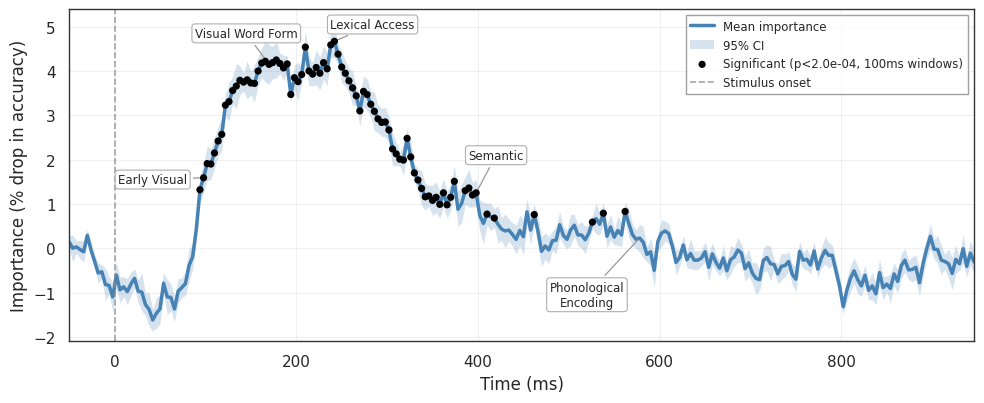


Figure 7 manuscript reproduction:
  source = historical cache
  peak = 242.0 ms
  drop = 4.67%


In [17]:
sem = std / np.sqrt(n_repeats_fig7)
ci95 = 1.96 * sem

fig, ax = plt.subplots(figsize=(10, 4.2))

ax.plot(
    times_ms,
    importance,
    color="steelblue",
    linewidth=2.5,
    label="Mean importance",
)
ax.fill_between(
    times_ms,
    importance - ci95,
    importance + ci95,
    color="steelblue",
    alpha=0.22,
    linewidth=0,
    label="95% CI",
)

if np.any(significant):
    ax.scatter(
        times_ms[significant],
        importance[significant],
        s=27,
        color="black",
        edgecolor="none",
        zorder=6,
        label=(
            f"Significant (p<{bonferroni_threshold:.1e}, "
            f"{window_size_ms_fig7:.0f}ms windows)"
        ),
    )

ax.axvline(
    0.0,
    color="#888888",
    linestyle="--",
    linewidth=1.2,
    alpha=0.75,
    label="Stimulus onset",
)


def nearest_idx(ms):
    return int(np.argmin(np.abs(times_ms - ms)))


annotation_specs = [
    ("Early Visual", 100, 42, 1.55),
    ("Visual Word Form", 170, 145, 4.85),
    ("Lexical Access", peak_time_ms, peak_time_ms + 42, 5.05),
    ("Semantic", 400, 420, 2.10),
    # Coordinates used for the manuscript figure.
    ("Phonological\nEncoding", 580, 520, -1.05),
]

for text, target_ms, text_x, text_y in annotation_specs:
    idx = nearest_idx(target_ms)
    ax.annotate(
        text,
        xy=(times_ms[idx], importance[idx]),
        xytext=(text_x, text_y),
        textcoords="data",
        ha="center",
        va="center",
        fontsize=8.5,
        bbox=dict(
            boxstyle="round,pad=0.25",
            facecolor="white",
            edgecolor="#AAAAAA",
            linewidth=0.8,
            alpha=0.95,
        ),
        arrowprops=dict(
            arrowstyle="-",
            color="#999999",
            linewidth=0.9,
        ),
    )

ax.set_xlabel("Time (ms)")
ax.set_ylabel("Importance (% drop in accuracy)")
ax.set_xlim(times_ms[0], times_ms[-1])
ax.set_ylim(-2.1, 5.4)
ax.grid(alpha=0.28, linewidth=0.8)

ax.legend(
    loc="upper right",
    frameon=True,
    fancybox=False,
    edgecolor="#888888",
    fontsize=8.5,
)

for spine in ax.spines.values():
    spine.set_visible(True)
    spine.set_color("#333333")
    spine.set_linewidth(1.0)

fig.tight_layout()
fig.savefig(
    FIG_DIR / "figure7_temporal_importance.pdf",
    bbox_inches="tight",
    facecolor="white",
)
fig.savefig(
    FIG_DIR / "figure7_temporal_importance.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

print(
    "\nFigure 7 manuscript reproduction:\n"
    f"  source = {'fresh rerun' if RECOMPUTE_PFI else 'historical cache'}\n"
    f"  peak = {peak_time_ms:.1f} ms\n"
    f"  drop = {peak_importance:.2f}%"
)


# Figure 8 — Spatial–temporal progression

Figure 8 uses the **1,000 unstandardised test-set epochs**:

- pre-stimulus baseline correction from the first stored sample to 0 ms;
- planar gradiometers;
- trial averaging;
- local RMS around each target latency (approximately ±25 ms);
- one common colour scale across all five topographies;
- the manuscript's pineapple sequential colour map.

MNE stores planar-gradiometer data internally in **T/m**. The plot therefore
keeps those numerical values in T/m; the Figure 8 colourbar in the manuscript
should use the same unit.

The middle (`M250`) map uses the Figure 7 peak. With the default historical
Figure 7 cache this reproduces the manuscript's ~242 ms map. If
`RECOMPUTE_PFI=True`, it instead follows the newly regenerated peak.


Applying baseline correction (mode: mean)


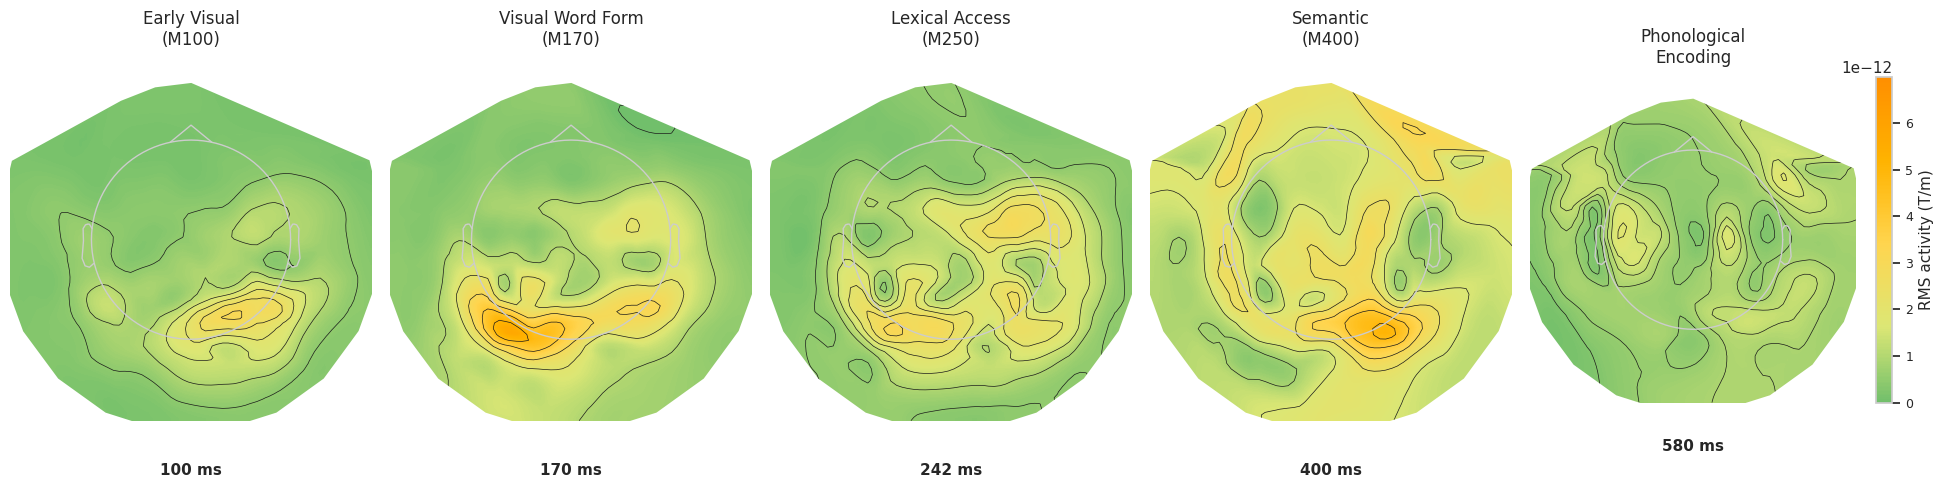

Figure 8 requested / nearest sampled latencies:
  Early Visual (M100)            requested  100.0 ms; nearest sample  100.0 ms
  Visual Word Form (M170)        requested  170.0 ms; nearest sample  172.0 ms
  Lexical Access (M250)          requested  242.0 ms; nearest sample  240.0 ms
  Semantic (M400)                requested  400.0 ms; nearest sample  400.0 ms
  Phonological Encoding          requested  580.0 ms; nearest sample  580.0 ms


In [18]:
BAD_CHANNELS = [
    "MEG0911", "MEG0912", "MEG0913",
    "MEG0921", "MEG0922", "MEG0923", "MEG1411",
]

with h5py.File(paths["test"], "r") as f:
    topo_data = np.asarray(f["data"][:], dtype=np.float32)
    topo_times = np.asarray(f["times"][:], dtype=float)
    ch_names = [
        v.decode() if isinstance(v, (bytes, bytearray)) else str(v)
        for v in f["channel_names"][:]
    ]
    ch_types = [
        v.decode() if isinstance(v, (bytes, bytearray)) else str(v)
        for v in f["channel_types"][:]
    ]
    sensor_xyz = np.asarray(f["sensor_xyz"][:], dtype=float)

sfreq = float(round(1.0 / np.median(np.diff(topo_times))))
tmin = float(topo_times[0])

assert sfreq == 250.0
assert topo_data.shape == (1000, 306, 250)

info = mne.create_info(
    ch_names=ch_names,
    sfreq=sfreq,
    ch_types=ch_types,
)

for idx in range(len(ch_names)):
    info["chs"][idx]["loc"][:3] = sensor_xyz[idx]
    norm = np.linalg.norm(sensor_xyz[idx])
    if norm > 0:
        info["chs"][idx]["loc"][9:12] = sensor_xyz[idx] / norm

info["bads"] = [ch for ch in BAD_CHANNELS if ch in ch_names]

epochs = mne.EpochsArray(
    topo_data,
    info=info,
    tmin=tmin,
    verbose=False,
)
epochs.apply_baseline((tmin, 0.0))
evoked_grad = epochs.average().pick("grad")

if 200.0 <= peak_time_ms <= 300.0:
    lexical_time = peak_time_ms / 1000.0
else:
    lexical_time = 0.250

time_windows = {
    "Early Visual\n(M100)": 0.100,
    "Visual Word Form\n(M170)": 0.170,
    "Lexical Access\n(M250)": lexical_time,
    "Semantic\n(M400)": 0.400,
    "Phonological\nEncoding": 0.580,
}


def truncate_cmap(cmap, minval=0.3, maxval=1.0, N=256):
    colors = cmap(np.linspace(minval, maxval, N))
    return LinearSegmentedColormap.from_list(
        f"{cmap.name}_trunc",
        colors,
    )


pineapple_seq = LinearSegmentedColormap.from_list(
    "pineapple_seq",
    [
        "#1b5e20",
        "#388e3c",
        "#66bb6a",
        "#dce775",
        "#ffd54f",
        "#ffb300",
        "#ff8f00",
    ],
    N=256,
)
cmap_custom = truncate_cmap(
    pineapple_seq,
    minval=0.35,
    maxval=1.0,
)

half_window = int(0.025 * sfreq)


def local_rms(evoked, time_sec):
    time_idx = int(np.argmin(np.abs(evoked.times - time_sec)))
    start_idx = max(0, time_idx - half_window)
    end_idx = min(
        len(evoked.times),
        time_idx + half_window,
    )
    data_window = evoked.data[:, start_idx:end_idx]
    return np.sqrt(np.mean(data_window ** 2, axis=1))


# MNE stores planar gradiometers internally in T/m.
# Keep the native numerical scale so the topographies match the manuscript.
topo_values = {
    label: local_rms(evoked_grad, t)
    for label, t in time_windows.items()
}
vmax_global = max(
    float(np.max(v))
    for v in topo_values.values()
)

fig, axes = plt.subplots(
    1,
    len(time_windows),
    figsize=(20, 4.5),
)

im = None
for idx, ((label, time_sec), ax) in enumerate(
    zip(time_windows.items(), axes)
):
    data_to_plot = topo_values[label]

    im, _ = mne.viz.plot_topomap(
        data_to_plot,
        evoked_grad.info,
        axes=ax,
        show=False,
        contours=6,
        cmap=cmap_custom,
        sensors=False,
        names=None,
        sphere=None,
        vlim=(0, vmax_global),
        size=4,
    )

    ax.set_title(label, fontsize=12, pad=10)
    requested_ms = int(round(time_sec * 1000))
    ax.text(
        0.5,
        -0.15,
        f"{requested_ms} ms",
        transform=ax.transAxes,
        ha="center",
        fontsize=11,
        weight="bold",
    )

divider = make_axes_locatable(axes[-1])
cax = divider.append_axes("right", size="5%", pad=0.2)
cbar = plt.colorbar(im, cax=cax)
cbar.set_label("RMS activity (T/m)", fontsize=11)
cbar.ax.tick_params(labelsize=9)

plt.tight_layout(rect=[0, 0.02, 0.98, 0.94])
fig.savefig(
    FIG_DIR / "figure8_spatial_temporal_progression.pdf",
    bbox_inches="tight",
    facecolor="white",
)
fig.savefig(
    FIG_DIR / "figure8_spatial_temporal_progression.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white",
)
plt.show()

print("Figure 8 requested / nearest sampled latencies:")
for label, time_sec in time_windows.items():
    actual_idx = int(
        np.argmin(np.abs(evoked_grad.times - time_sec))
    )
    requested_ms = time_sec * 1000
    actual_ms = evoked_grad.times[actual_idx] * 1000
    clean_label = label.replace("\n", " ")
    print(
        f"  {clean_label:<30} "
        f"requested {requested_ms:6.1f} ms; "
        f"nearest sample {actual_ms:6.1f} ms"
    )

## Summary


In [19]:
print("=" * 72)
print("MEGNIST PAPER REPRODUCTION SUMMARY")
print("=" * 72)
print(f"Figure 5 best architecture:       {best_arch}")
print(
    f"Figure 5 1024 val/test:           "
    f"{np.mean(val_data[1024]):.1f} ± {np.std(val_data[1024]):.1f}% / "
    f"{np.mean(test_data[1024]):.1f} ± {np.std(test_data[1024]):.1f}%"
)
print(
    f"Released seed-47 val/test:        "
    f"{val_acc:.1f}% / {test_acc:.1f}%"
)
print(
    f"Figure 6 observed test accuracy:  "
    f"{observed_test_acc:.1f}%"
)
print(
    f"Figure 6 99th percentile:         "
    f"{threshold_99:.1f}%"
)
print(
    f"Figure 6 corrected p-value:       "
    f"{p_value:.8f}"
)
print(
    f"Figure 7 peak:                    "
    f"{peak_time_ms:.1f} ms"
)
print(
    f"Figure 7 peak drop:               "
    f"{peak_importance:.2f}%"
)
print(f"Figures saved to:                 {FIG_DIR}")
print("Full retraining:                     scripts/run_hyperparameter_search.py")
print("Figure 8 colourbar unit:             T/m (MNE native gradiometer units)")
print("=" * 72)

print("\nGenerated files:")
for p in sorted(FIG_DIR.iterdir()):
    print(" ", p.name)

archive = shutil.make_archive(
    str(WORK_DIR / "MegNIST_paper_figures"),
    "zip",
    root_dir=FIG_DIR,
)
print("\nFigure archive:", archive)

MEGNIST PAPER REPRODUCTION SUMMARY
Figure 5 best architecture:       1024
Figure 5 1024 val/test:           26.8 ± 0.7% / 22.6 ± 0.7%
Released seed-47 val/test:        27.1% / 22.6%
Figure 6 observed test accuracy:  22.6%
Figure 6 99th percentile:         12.2%
Figure 6 corrected p-value:       0.00001000
Figure 7 peak:                    242.0 ms
Figure 7 peak drop:               4.67%
Figures saved to:                 /content/MegNIST_paper/figures
Full retraining:                     scripts/run_hyperparameter_search.py
Figure 8 colourbar unit:             T/m (MNE native gradiometer units)

Generated files:
  figure5_model_selection.pdf
  figure5_model_selection.png
  figure6_permutation_test.pdf
  figure6_permutation_test.png
  figure7_temporal_importance.pdf
  figure7_temporal_importance.png
  figure8_spatial_temporal_progression.pdf
  figure8_spatial_temporal_progression.png

Figure archive: /content/MegNIST_paper/MegNIST_paper_figures.zip
